# League of Legends Match Prediction - Phase 1

## Project Overview
This notebook focuses on the first phase of a machine learning project to predict the outcome of League of Legends ranked games based on statistics from the first 10 minutes. 

**Dataset:** [League of Legends Diamond Ranked Games (10 min)](https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min)
**Target:** `blueWins` (1 if Blue team wins, 0 otherwise)
**Author:** Léo Joly--Jehenne, Quentin Le Goff  



## Dataset Access Instructions

### Download Using Kaggle API
```bash
# Install kaggle API
pip install kaggle

# Download dataset (requires Kaggle API credentials)
kaggle datasets download -d bobbyscience/league-of-legends-diamond-ranked-games-10-min
unzip league-of-legends-diamond-ranked-games-10-min.zip
```

## Table of Contents
1. [Environment Initialization](#1.-Environment-Initialization)
2. [Data Exploratory Analysis (EDA)](#2.-Data-Exploratory-Analysis-(EDA))
3. [Unsupervised Exploration](#3.-Unsupervised-Exploration)
4. [Data Preprocessing](#4.-Data-Preprocessing)
5. [Baseline Modeling](#5.-Baseline-Modeling)

## 1. Environment Initialization

In [4]:
# Standard ML Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Configuration
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Data Exploratory Analysis

In [ ]:
# Load the dataset
df = pd.read_csv('./data/high_diamond_ranked_10min.csv') #verify location of csv

# Display first few rows
df.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [ ]:
# Dataset Summary
print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (9879, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 n

In [8]:
# Statistical Summary
df.describe()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


In [9]:
# Check for missing values
df.isnull().sum().sum()

np.int64(0)

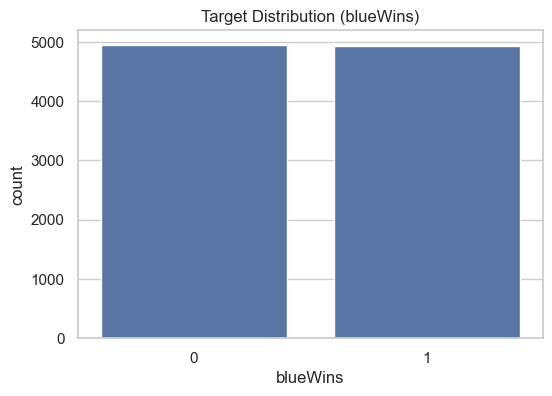

In [10]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='blueWins', data=df)
plt.title('Target Distribution (blueWins)')
plt.show()

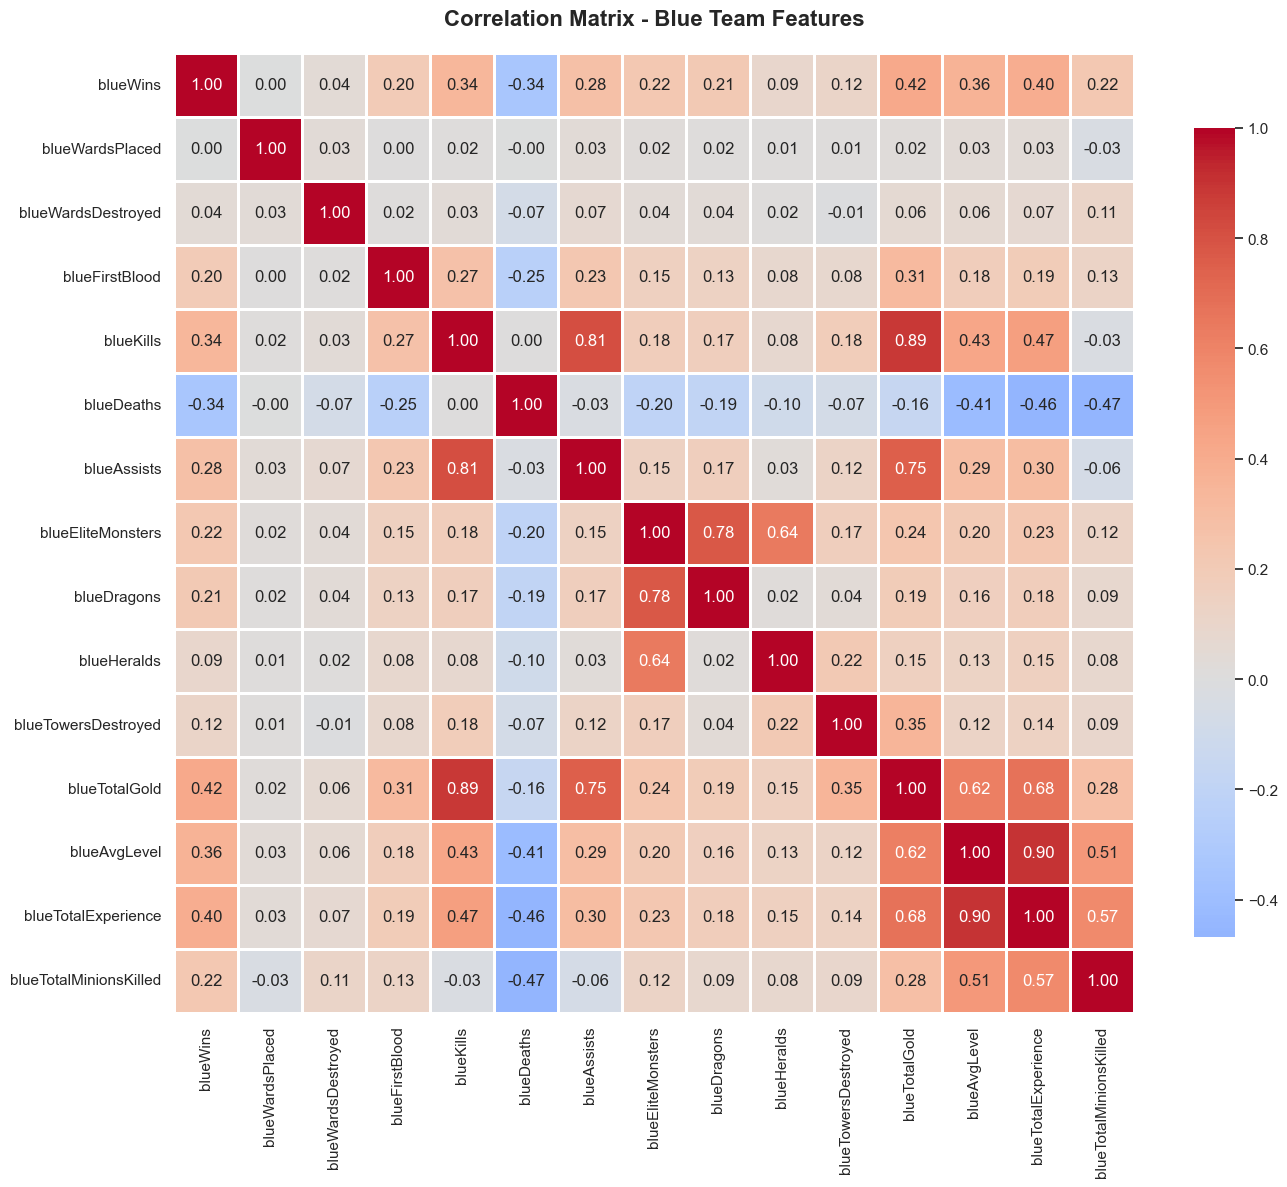


TOP FEATURES CORRELATED WITH BLUE WINS
blueWins                  1.000000
blueTotalGold             0.417213
blueTotalExperience       0.396141
blueAvgLevel              0.357820
blueDeaths                0.339297
blueKills                 0.337358
blueAssists               0.276685
blueTotalMinionsKilled    0.224909
blueEliteMonsters         0.221944
blueDragons               0.213768
Name: blueWins, dtype: float64


In [19]:
# Correlation matrix for blue team features
blue_features = [col for col in df.columns if col.startswith('blue') and df[col].dtype in ['int64', 'float64']]

if blue_features:
    # Limit to reasonable number for visualization
    blue_features_subset = blue_features[:15] if len(blue_features) > 15 else blue_features
    
    corr_matrix = df[blue_features_subset].corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix - Blue Team Features', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Top correlations with target
    if 'blueWins' in blue_features_subset:
        target_corr = corr_matrix['blueWins'].abs().sort_values(ascending=False)
        print("\n" + "="*80)
        print("TOP FEATURES CORRELATED WITH BLUE WINS")
        print("="*80)
        print(target_corr.head(10))
else:
    print("No numeric blue team features found")

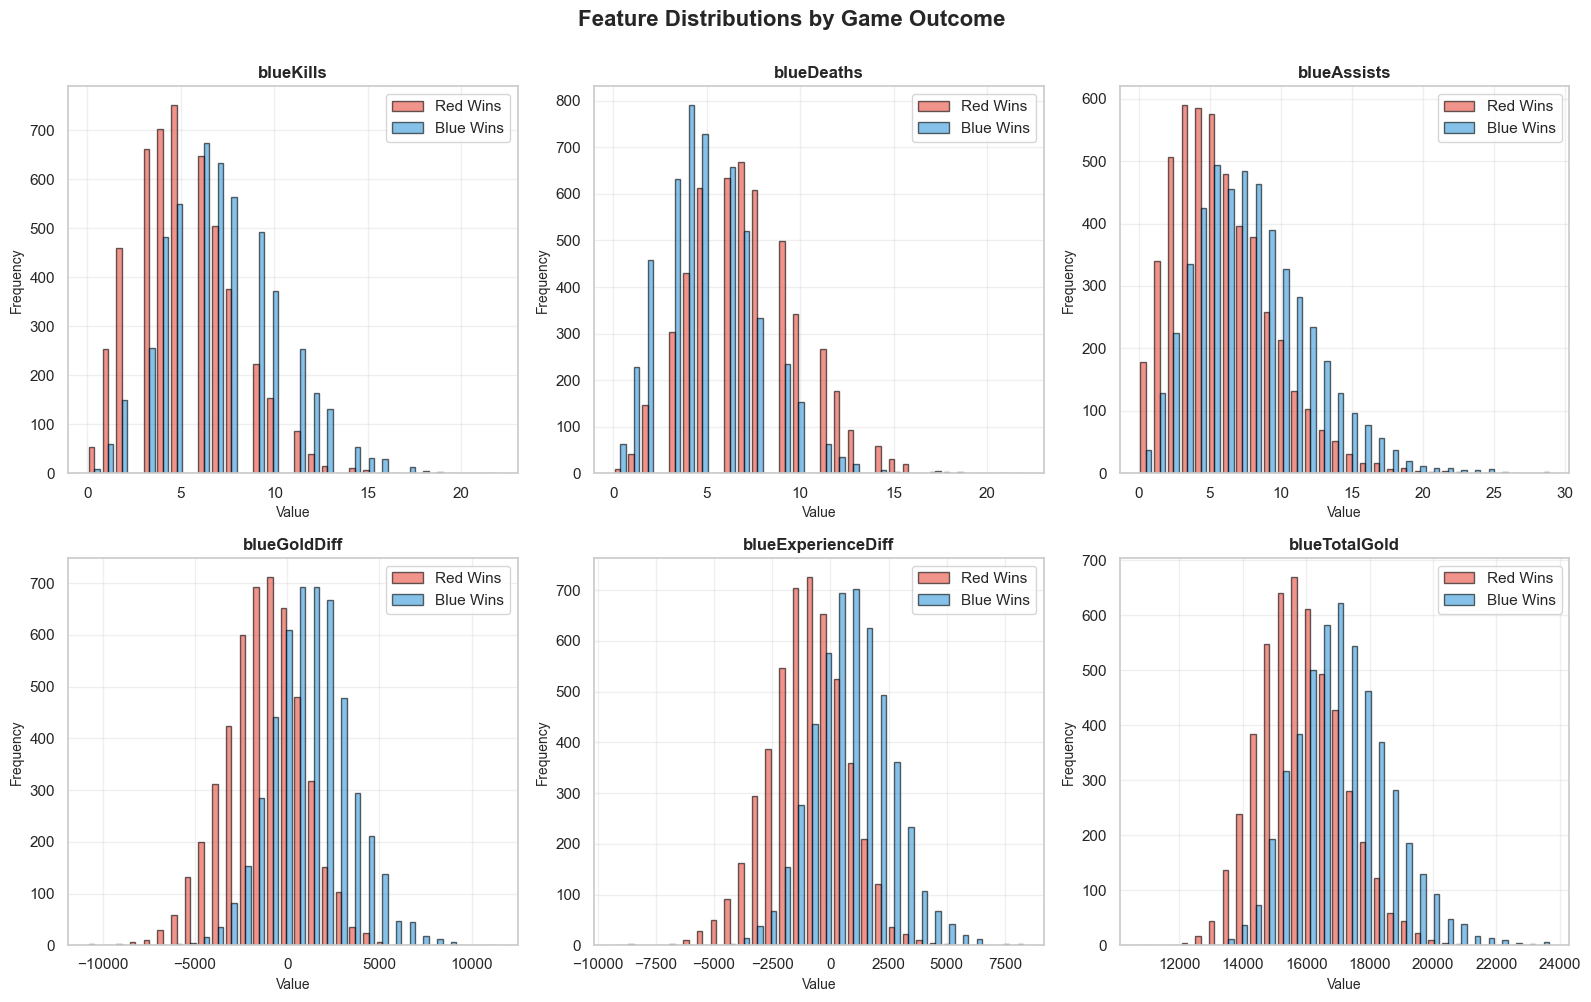

In [21]:
# Compare key metrics between wins and losses
comparison_features = [
    'blueKills', 'blueDeaths', 'blueAssists',
    'blueGoldDiff', 'blueExperienceDiff', 'blueTotalGold'
]

comparison_features = [f for f in comparison_features if f in df.columns]

if comparison_features and 'blueWins' in df.columns:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(comparison_features):
        if i < len(axes):
            df_wins = df[df['blueWins'] == 1][feature]
            df_losses = df[df['blueWins'] == 0][feature]
            
            axes[i].hist([df_losses, df_wins], bins=30, label=['Red Wins', 'Blue Wins'],
                        color=['#e74c3c', '#3498db'], alpha=0.6, edgecolor='black')
            axes[i].set_title(feature, fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Value', fontsize=10)
            axes[i].set_ylabel('Frequency', fontsize=10)
            axes[i].legend()
            axes[i].grid(alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(comparison_features), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Feature Distributions by Game Outcome', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("Comparison features or target not found")

## 3. Unsupervised Exploration
We will use PCA to reduce dimensionality and see if there are distinct clusters or patterns.

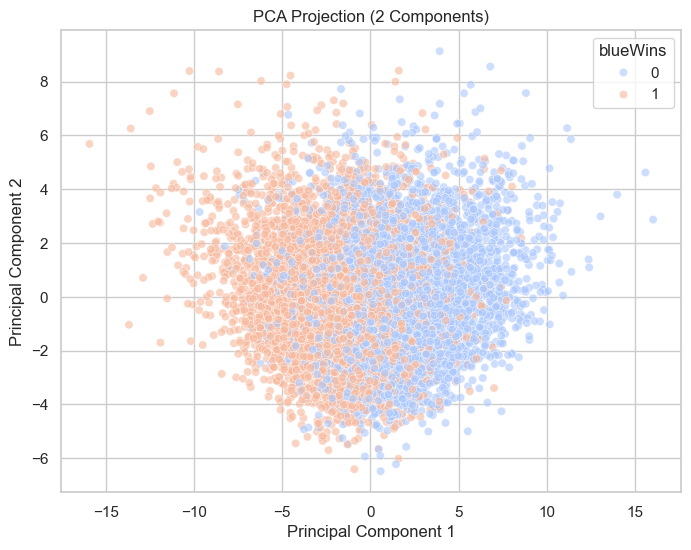

In [13]:
# Drop gameId and target for unsupervised learning
X_unsupervised = df.drop(['gameId', 'blueWins'], axis=1)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['blueWins'], palette='coolwarm', alpha=0.6)
plt.title('PCA Projection (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## 4. Data Preprocessing

In [14]:
# Feature Engineering Ideas
# The dataset already contains 'Diff' features (e.g., blueGoldDiff), which are highly correlated with the totals.
# We can check if we want to keep all features or remove highly correlated ones to reduce multicollinearity.

# For this baseline, we will use all features except gameId.
X = df.drop(['gameId', 'blueWins'], axis=1)
y = df['blueWins']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Baseline Modeling

In [15]:
# 1. Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:
Accuracy: 0.7328
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       983
           1       0.73      0.73      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976



In [17]:
# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train) # Tree-based models don't strictly require scaling, but it doesn't hurt
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.7227
              precision    recall  f1-score   support

           0       0.72      0.73      0.72       983
           1       0.73      0.71      0.72       993

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



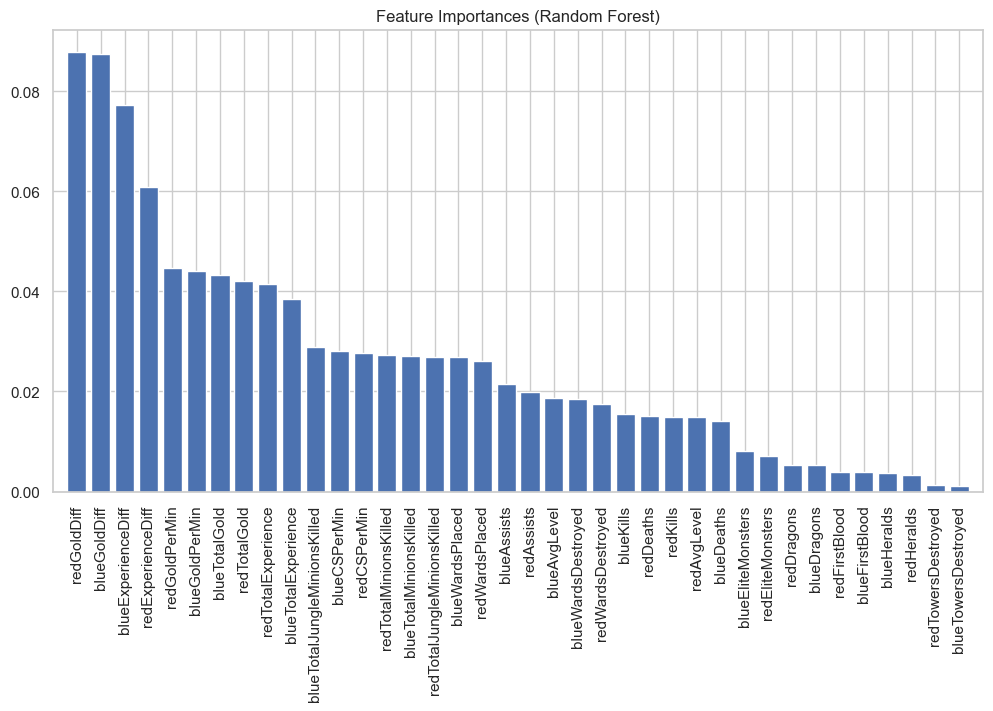

In [18]:
# Feature Importance (Random Forest)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

## Conclusion
We have successfully loaded the data, performed EDA, and established baseline models. 
The Gold Difference and Experience Difference are likely the most dominant features. 
Future work can involve more complex feature engineering, hyperparameter tuning, and trying deep learning models.